This first piece of code loads the National Planning Policy Framework document from a pdf file, and extracts the text into strings - one string per page. So you are going from a 82 page pdf to something that our python environment can query and interrogate. It is saved in an object called 'pages'

In [14]:
import pypdf
from pathlib import Path

# ── Config ──────────────────────────────────────────────────────────────────
PDF_PATH = Path("../data/nppf.pdf")
# ── Step 1: Load the PDF and extract raw text page by page ──────────────────
reader = pypdf.PdfReader(PDF_PATH)
print(f"Total pages: {len(reader.pages)}")

pages = []
for i, page in enumerate(reader.pages):
    text = page.extract_text()
    if text:                          # some pages are blank or image-only
        pages.append({"page": i + 1, "text": text.strip()})

print(f"Pages with extractable text: {len(pages)}")
print(f"\n--- Sample: page 1 (first 300 chars) ---")
print(pages[23]["text"][:5000])

Total pages: 82
Pages with extractable text: 82

--- Sample: page 1 (first 300 chars) ---
24  
6. Building a strong, competitive economy 
85. Planning policies and decisions should help create the conditions in which 
businesses can invest, expand and adapt. Significant weight should be placed on 
the need to support economic growth and productivity, taking into account both local 
business needs and wider opportunities for development. The approach taken 
should allow each area to build on its strengths, counter any weaknesses and 
address the challenges of the future. This is particularly important where Britain can 
be a global leader in driving innovation, and in areas with high levels of productivity, 
which should be able to capitalise on their performance and potential. 
 
86. Planning policies should: 
 
a) set out a clear economic vision and strategy which positively and proactively 
encourages sustainable economic growth, having regard to the national industrial 
strategy43 a

This section section is where the chunking occurs - it takes the 82 strings and then splits them up into chunks of characters - in this case 500 characters, with a 50 character overlap.

The recursive character text splitter tries to break down the string into chunks by splitting them by new paragraphs, new lines, and then by punctuation. This tries to preserve paragraph structure where possible - keeping the chunks in paragraphs should preserve the way they were written so that they can be recalled via the retrieval mechanism in a useful way.

Chunking Strategy - there are a number of constraints that mean the chunking strategy is a very important element of how this process works:

(1) embedding granularity - when you pass each chunk through the encoder, it produces a single vector (size depends on the embedding model used - e.g. 384 dimension) that is the average of the embeddings as they have passed through the encoder, each updating their embedding values depending on the attention scores and other parts of the model - i.e. each token can pay attention to all other tokens and so the final output of each token would contain context from all other tokens. But it is a summary of the entire semantic content of the input - so if the chunk is too big and contains multiple issues, then this may got buried in the process and subsequently be hard to retrieve.

(2) LLM context window - you don't want to feed the whole NPPF (70 pages and c140,000 tokens) into the LLM with a user query - it would be slow, expensive and may struggle to find the right content.

Trade off - if the chunks are too small it may lose context and just have partial sentences; if the chunks are too big the embedding can become diluted across multiple topics and retrieval precision drops. Empirically around 256 - 512 tokens works well for policy documents - where each chunk is coherent but not too large to become diluted.

Where you cut is also very important - sentence-boundary or paragraph-boundary splitter retains the structure of sentences, rather than naively splitting after a certain number of characters.

Chunking options:
Option 1: recursive splitting by paragraphs and new lines, then punctuation, with a 500 char limit. Led to the sections with the NPPF being split that should be kept together - as they are often of over 500 chars.
Option 2: no preferred separator - just cut at chunk_size = 500 chars. All the right length but doesn't result in a helpful split.
Option 3: sentence - split across entire whole sentences. Struggles with the formatting of the document with paragraph and section titles, and some very big chunks.
Option 4: paragraphs - split across whole paragraphs, based on numbered paragraph structure of the document. This worked better but results in some very big chunks (>3,000 characters) and high avg char length (c700) and high std (583)
Option 5: hybrid - use paragraphs and then fall back on recursive split. Max size is 999 chars, with avg size of 576 and std of 281 - this seems to be best approach going forwards.

In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ── Config ───────────────────────────────────────────────────────────────────
CHUNK_SIZE = 500
CHUNK_OVERLAP = 50

# ── Step 2: Concatenate all page text, keeping page metadata ─────────────────
# We'll chunk per-page so we can attach page number metadata to each chunk
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""]  # tries these in order
)

chunks = []
for page in pages:
    page_chunks = splitter.split_text(page["text"])
    for i, chunk_text in enumerate(page_chunks):
        chunks.append({
            "chunk_id": f"p{page['page']}_c{i}",
            "page": page["page"],
            "text": chunk_text
        })

print(f"Total chunks: {len(chunks)}")
print(f"Avg chunk length: {sum(len(c['text']) for c in chunks) / len(chunks):.0f} chars")
print(f"\n--- Sample chunk ---")
print(f"ID: {chunks[10]['chunk_id']}")
print(f"Page: {chunks[10]['page']}")
print(f"Text: {chunks[10]['text']}")

Total chunks: 493
Avg chunk length: 424 chars

--- Sample chunk ---
ID: p4_c4
Page: 4
Text: policy statements form part of the overall framework of national planning policy, and 
may be a material consideration in preparing plans and making decisions on 
planning applications. 
 
6. Other statements of government policy may be material when preparing plans or 
deciding applications, such as relevant Written Ministerial Statements and endorsed 
recommendations of the National Infrastructure Commission.


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ── Strategy 2: Fixed-size character splitting ────────────────────────────────
# No respect for sentence or paragraph boundaries - pure character count.
# This is the naive baseline to show what you're improving on.
from langchain_text_splitters import CharacterTextSplitter

fixed_splitter = CharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separator=""  # no preferred separator - just cut at chunk_size
)

fixed_chunks = []
for page in pages:
    page_chunks = fixed_splitter.split_text(page["text"])
    for i, chunk_text in enumerate(page_chunks):
        fixed_chunks.append({
            "chunk_id": f"p{page['page']}_c{i}",
            "page": page["page"],
            "text": chunk_text
        })

print(f"Strategy 2 — Fixed-size character splitting")
print(f"  Total chunks: {len(fixed_chunks)}")
print(f"  Avg length: {sum(len(c['text']) for c in fixed_chunks) / len(fixed_chunks):.0f} chars")

Strategy 2 — Fixed-size character splitting
  Total chunks: 499
  Avg length: 457 chars


In [17]:
# ── Strategy 3: Sentence-boundary splitting ───────────────────────────────────
# Split on sentence endings first, then group sentences into ~500 char chunks.
# Requires: pip install nltk
import nltk
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize

def sentence_chunk(text, target_size=500, overlap_sentences=1):
    """Group sentences into chunks of approximately target_size chars."""
    sentences = sent_tokenize(text)
    chunks = []
    current = []
    current_len = 0

    for sent in sentences:
        if current_len + len(sent) > target_size and current:
            chunks.append(" ".join(current))
            # overlap: carry last N sentences into next chunk
            current = current[-overlap_sentences:]
            current_len = sum(len(s) for s in current)
        current.append(sent)
        current_len += len(sent)

    if current:
        chunks.append(" ".join(current))

    return chunks

sentence_chunks = []
for page in pages:
    page_chunks = sentence_chunk(page["text"], target_size=500, overlap_sentences=1)
    for i, chunk_text in enumerate(page_chunks):
        sentence_chunks.append({
            "chunk_id": f"p{page['page']}_c{i}",
            "page": page["page"],
            "text": chunk_text
        })

print(f"Strategy 3 — Sentence-boundary splitting")
print(f"  Total chunks: {len(sentence_chunks)}")
print(f"  Avg length: {sum(len(c['text']) for c in sentence_chunks) / len(sentence_chunks):.0f} chars")

Strategy 3 — Sentence-boundary splitting
  Total chunks: 669
  Avg length: 499 chars


Added a fourth strategy after testing recursive, plain 500 char and sentence boundary splitting - paragraph aware chunking strategy.

In [18]:
import re

def paragraph_aware_chunk(pages, min_length=100):
    """
    Split NPPF text on numbered paragraph boundaries (e.g. '51.', '52.').
    Each chunk = one complete numbered paragraph.
    
    The regex \n\d+\. matches a newline followed by one or more digits and a
    full stop — the exact pattern the NPPF uses for every paragraph number.
    
    min_length: discard chunks shorter than this (catches stray headings/numbers)
    """
    chunks = []
    
    for page in pages:
        text = page["text"]
        
        # Find all positions where a new numbered paragraph starts
        # re.split keeps the delimiter if wrapped in a capturing group
        splits = re.split(r'(\n\d+\.)', text)
        
        # re.split with a capturing group gives:
        # [pre-first-para, '\n51.', para_text, '\n52.', para_text, ...]
        # Reconstruct by zipping delimiters back onto their text
        reconstructed = [splits[0]]  # text before paragraph 1 (usually page header)
        for i in range(1, len(splits) - 1, 2):
            # delimiter ('\n51.') + following text joined together
            reconstructed.append(splits[i] + splits[i + 1])
        
        for i, chunk_text in enumerate(reconstructed):
            chunk_text = chunk_text.strip()
            if len(chunk_text) >= min_length:  # discard stray headings
                chunks.append({
                    "chunk_id": f"p{page['page']}_c{i}",
                    "page": page["page"],
                    "text": chunk_text
                })
    
    return chunks

para_chunks = paragraph_aware_chunk(pages, min_length=100)

print(f"Strategy 4 — Paragraph-aware splitting")
print(f"  Total chunks: {len(para_chunks)}")
print(f"  Avg length:   {sum(len(c['text']) for c in para_chunks) / len(para_chunks):.0f} chars")
print(f"  Min: {min(len(c['text']) for c in para_chunks)}")
print(f"  Max: {max(len(c['text']) for c in para_chunks)}")

Strategy 4 — Paragraph-aware splitting
  Total chunks: 291
  Avg length:   704 chars
  Min: 102
  Max: 3263


In [19]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def hybrid_chunk(pages, max_chunk_size=1000, min_length=100):
    """
    Primary strategy: split on NPPF paragraph numbers (\n\d+\.)
    Secondary strategy: if a paragraph chunk exceeds max_chunk_size,
    apply RecursiveCharacterTextSplitter to that chunk only.
    
    This preserves complete paragraphs where possible, while preventing
    very long sub-clause paragraphs from producing oversized embeddings.
    """
    # Fallback splitter for oversized paragraphs only
    fallback_splitter = RecursiveCharacterTextSplitter(
        chunk_size=max_chunk_size,
        chunk_overlap=50,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    
    chunks = []
    
    for page in pages:
        text = page["text"]
        
        # Step 1: paragraph-aware primary split (same logic as S4)
        splits = re.split(r'(\n\d+\.)', text)
        reconstructed = [splits[0]]
        for i in range(1, len(splits) - 1, 2):
            reconstructed.append(splits[i] + splits[i + 1])
        
        chunk_index = 0
        for para_text in reconstructed:
            para_text = para_text.strip()
            
            if len(para_text) < min_length:
                continue
            
            if len(para_text) <= max_chunk_size:
                # Step 2a: paragraph fits — keep it intact
                chunks.append({
                    "chunk_id": f"p{page['page']}_c{chunk_index}",
                    "page": page["page"],
                    "text": para_text
                })
                chunk_index += 1
            else:
                # Step 2b: paragraph too large — apply recursive splitter
                sub_chunks = fallback_splitter.split_text(para_text)
                for sub_text in sub_chunks:
                    if len(sub_text) >= min_length:
                        chunks.append({
                            "chunk_id": f"p{page['page']}_c{chunk_index}",
                            "page": page["page"],
                            "text": sub_text
                        })
                        chunk_index += 1
    
    return chunks

hybrid_chunks = hybrid_chunk(pages, max_chunk_size=1000, min_length=100)

h_lengths = [len(c["text"]) for c in hybrid_chunks]
print(f"Strategy 5 — Hybrid (paragraph-aware + recursive fallback)")
print(f"  Total chunks: {len(hybrid_chunks)}")
print(f"  Avg length:   {sum(h_lengths) / len(h_lengths):.0f} chars")
print(f"  Std:          {np.std(h_lengths):.0f}")
print(f"  Min: {min(h_lengths)},  Max: {max(h_lengths)}")

Strategy 5 — Hybrid (paragraph-aware + recursive fallback)
  Total chunks: 355
  Avg length:   576 chars
  Std:          281
  Min: 102,  Max: 999


Now run a visualisation to compare all four:

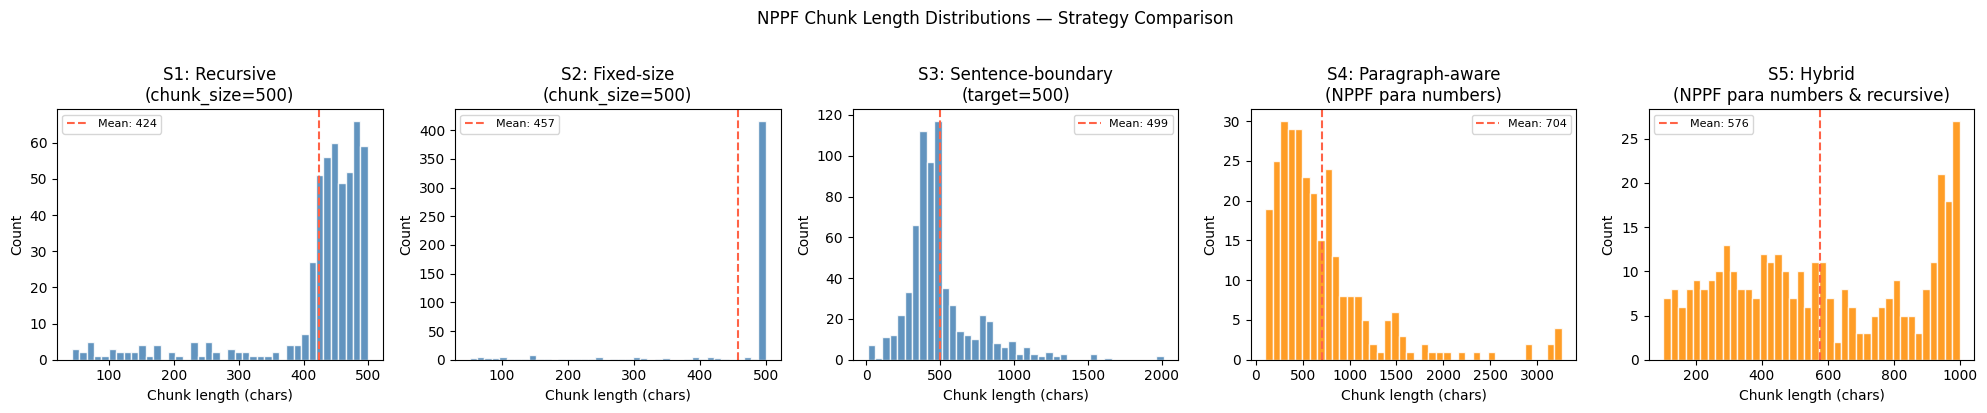

Strategy                                 N   Mean    Std    Min    Max
-----------------------------------------------------------------
S1: Recursive                          493    424     95     43    499
S2: Fixed-size                         499    457    110     51    500
S3: Sentence-boundary                  669    499    246      8   2012
S4: Paragraph-aware                    291    704    583    102   3263
S5: Strategy 5 — Hybrid                355    576    281    102    999


In [28]:
# ── Compare chunk length distributions ───────────────────────────────────────
s1_lengths = [len(c["text"]) for c in chunks]           # your recursive splitter
s2_lengths = [len(c["text"]) for c in fixed_chunks]
s3_lengths = [len(c["text"]) for c in sentence_chunks]
s4_lengths = [len(c["text"]) for c in para_chunks]
s5_lengths = [len(c["text"]) for c in hybrid_chunks]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
labels = [
    "S1: Recursive\n(chunk_size=500)",
    "S2: Fixed-size\n(chunk_size=500)",
    "S3: Sentence-boundary\n(target=500)",
    "S4: Paragraph-aware\n(NPPF para numbers)",
    "S5: Hybrid\n(NPPF para numbers & recursive)"
]
all_chunks = [s1_lengths, s2_lengths, s3_lengths, s4_lengths, s5_lengths]
colours = ["steelblue", "steelblue", "steelblue", "darkorange", "darkorange"]

for ax, lengths, label, colour in zip(axes, all_chunks, labels, colours):
    ax.hist(lengths, bins=40, color=colour, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(lengths), color="tomato", linestyle="--",
               label=f"Mean: {np.mean(lengths):.0f}")
    ax.set_title(label)
    ax.set_xlabel("Chunk length (chars)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("NPPF Chunk Length Distributions — Strategy Comparison", y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print(f"{'Strategy':<35} {'N':>6} {'Mean':>6} {'Std':>6} {'Min':>6} {'Max':>6}")
print("-" * 65)
for label, lengths in zip(
    ["S1: Recursive", "S2: Fixed-size", "S3: Sentence-boundary", "S4: Paragraph-aware", "S5: Strategy 5 — Hybrid"],
    all_chunks
):
    print(f"{label:<35} {len(lengths):>6} {np.mean(lengths):>6.0f} "
          f"{np.std(lengths):>6.0f} {min(lengths):>6} {max(lengths):>6}")

And a qualitative inspection to see what the outputs actually look like:

In [21]:
# ── Qualitative inspection: same page, all three strategies ──────────────────
# Pick a page with dense policy text - page 15 is a good candidate in the NPPF
INSPECT_PAGE = 15

print(f"{'='*60}")
print(f"STRATEGY 1 — Recursive (chunks from page {INSPECT_PAGE})")
print(f"{'='*60}")
for c in [c for c in chunks if c["page"] == INSPECT_PAGE]:
    print(f"\n[{c['chunk_id']}]\n{c['text']}\n{'-'*40}")

print(f"\n{'='*60}")
print(f"STRATEGY 2 — Fixed-size (chunks from page {INSPECT_PAGE})")
print(f"{'='*60}")
for c in [c for c in fixed_chunks if c["page"] == INSPECT_PAGE]:
    print(f"\n[{c['chunk_id']}]\n{c['text']}\n{'-'*40}")

print(f"\n{'='*60}")
print(f"STRATEGY 3 — Sentence-boundary (chunks from page {INSPECT_PAGE})")
print(f"{'='*60}")
for c in [c for c in sentence_chunks if c["page"] == INSPECT_PAGE]:
    print(f"\n[{c['chunk_id']}]\n{c['text']}\n{'-'*40}")

STRATEGY 1 — Recursive (chunks from page 15)

[p15_c0]
15  
51. Refusal of planning permission on grounds of prematurity will seldom be justified 
where a draft plan has yet to be submitted for examination; or – in the case of a 
neighbourhood plan – before the end of the local planning authority publicity period 
on the draft plan. Where planning permission is refused on grounds of prematurity, 
the local planning authority will need to indicate clearly how granting permission for
----------------------------------------

[p15_c1]
the development concerned would prejudice the outcome of the plan-making 
process. 
 
Tailoring planning controls to local circumstances 
52. Local planning authorities are encouraged to use Local Development Orders to set 
the planning framework for particular areas or categories of development where the 
impacts would be acceptable, and in particular where this would promote economic, 
social or environmental gains for the area.
---------------------------

In [22]:
INSPECT_PAGE = 15

for strategy_name, strategy_chunks in [
    ("STRATEGY 1 — Recursive", chunks),
    ("STRATEGY 4 — Paragraph-aware", para_chunks)
]:
    print(f"\n{'='*60}")
    print(f"{strategy_name} (chunks from page {INSPECT_PAGE})")
    print(f"{'='*60}")
    for c in [c for c in strategy_chunks if c["page"] == INSPECT_PAGE]:
        print(f"\n[{c['chunk_id']}]\n{c['text']}\n{'-'*40}")


STRATEGY 1 — Recursive (chunks from page 15)

[p15_c0]
15  
51. Refusal of planning permission on grounds of prematurity will seldom be justified 
where a draft plan has yet to be submitted for examination; or – in the case of a 
neighbourhood plan – before the end of the local planning authority publicity period 
on the draft plan. Where planning permission is refused on grounds of prematurity, 
the local planning authority will need to indicate clearly how granting permission for
----------------------------------------

[p15_c1]
the development concerned would prejudice the outcome of the plan-making 
process. 
 
Tailoring planning controls to local circumstances 
52. Local planning authorities are encouraged to use Local Development Orders to set 
the planning framework for particular areas or categories of development where the 
impacts would be acceptable, and in particular where this would promote economic, 
social or environmental gains for the area.
--------------------------

In [23]:
INSPECT_PAGE = 24

print(f"{'='*60}")
print(f"STRATEGY 5 — Hybrid (chunks from page {INSPECT_PAGE})")
print(f"{'='*60}")
for c in [c for c in hybrid_chunks if c["page"] == INSPECT_PAGE]:
    print(f"\n[{c['chunk_id']}] ({len(c['text'])} chars)\n{c['text']}\n{'-'*40}")

STRATEGY 5 — Hybrid (chunks from page 24)

[p24_c0] (649 chars)
85. Planning policies and decisions should help create the conditions in which 
businesses can invest, expand and adapt. Significant weight should be placed on 
the need to support economic growth and productivity, taking into account both local 
business needs and wider opportunities for development. The approach taken 
should allow each area to build on its strengths, counter any weaknesses and 
address the challenges of the future. This is particularly important where Britain can 
be a global leader in driving innovation, and in areas with high levels of productivity, 
which should be able to capitalise on their performance and potential.
----------------------------------------

[p24_c1] (954 chars)
86. Planning policies should: 
 
a) set out a clear economic vision and strategy which positively and proactively 
encourages sustainable economic growth, having regard to the national industrial 
strategy43 and any relevan